# Tutorial 1.10: Multi-Agent Supervisor Pattern

![](images/11_multi_agent_supervisor.svg)

## Databricks AgentBricks Architecture with LangGraph + MLflow

This notebook implements the **multi-agent supervisor pattern** popularized by [Databricks AgentBricks](https://docs.databricks.com/en/generative-ai/agent-bricks/multi-agent-supervisor.html). A **Supervisor** intelligently routes user queries to specialized subagents, then synthesizes their results into a unified response.

### What You'll Learn
1. Build a **supervisor agent** that intelligently routes queries to specialized subagents
2. Implement a **Genie agent** for structured data queries (pandas DataFrame)
3. Implement a **Knowledge Assistant** for document retrieval and policy Q&A
4. **Trace** the full supervisor-subagent execution hierarchy with MLflow
5. **Evaluate** routing accuracy, response quality, and orchestration with 3 evaluation layers

### Use Case: FEMA Disaster Response

We simulate a disaster response system where:
- **Genie** answers data questions: "How many disasters hit California in 2024?"
- **Knowledge Assistant** answers policy questions: "What are the evacuation protocols?"
- **Supervisor** routes and synthesizes when both are needed

### Prerequisites
- Completed previous notebooks (1.1-1.9)
- OpenAI API key or Databricks AI Gateway configured

### Estimated Time: 20-25 minutes

---
## Step 1: Environment Setup

In [1]:
# Install dependencies (all should already be in pyproject.toml)
!uv add langgraph langchain langchain-openai

print("Dependencies installed")

Resolved 278 packages in 10ms
Audited 269 packages in 0.19ms
Dependencies installed


In [2]:
import mlflow
import json
import hashlib
import numpy as np
import pandas as pd
from typing import TypedDict, List, Dict, Optional
from dotenv import load_dotenv

from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from utils.clnt_utils import (
    is_databricks_client,
    is_databricks_ai_gateway_client,
    get_databricks_ai_gateway_client,
    get_openai_client,
    get_ai_gateway_model_names,
    get_langchain_chat_openai_client,
    get_databricks_ai_gateway_langchain_client,
    get_databricks_langchain_chat_client,
)

# Load environment
load_dotenv()

print(f"MLflow version: {mlflow.__version__}")

MLflow version: 3.10.1


In [3]:
# Configure MLflow
mlflow.set_tracking_uri("http://localhost:5000")

# Determine provider and initialize clients
use_databricks_provider = is_databricks_client()
use_databricks_ai_gateway = is_databricks_ai_gateway_client()

if use_databricks_ai_gateway:
    client = get_databricks_ai_gateway_client()
    model_name = get_ai_gateway_model_names()[0]
    embed_model_name = get_ai_gateway_model_names()[1] if len(get_ai_gateway_model_names()) > 1 else "text-embedding-3-small"
    llm = get_databricks_ai_gateway_langchain_client(model_name, temperature=0.0)
    provider_name = "Databricks AI Gateway"
elif use_databricks_provider:
    client = get_openai_client()
    model_name = "gpt-4o"
    embed_model_name = "text-embedding-3-small"
    llm = get_databricks_langchain_chat_client(model_name, temperature=0.0)
    provider_name = "Databricks Workspace"
else:
    client = get_openai_client()
    model_name = "gpt-5-mini"
    embed_model_name = "text-embedding-3-small"
    llm = get_langchain_chat_openai_client(model_name, temperature=0.0)
    provider_name = "OpenAI"

# Enable LangGraph autologging (covers LangGraph via langchain integration)
mlflow.langchain.autolog()

EXPERIMENT_NAME = "10-Multi-Agent-Supervisor"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Provider: {provider_name}")
print(f"Model: {model_name}")
print(f"Embedding model: {embed_model_name}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"LangChain autologging: ENABLED")

2026/03/31 19:29:30 INFO mlflow.tracking.fluent: Experiment with name '10-Multi-Agent-Supervisor' does not exist. Creating a new experiment.


Provider: OpenAI
Model: gpt-5-mini
Embedding model: text-embedding-3-small
Tracking URI: http://localhost:5000
Experiment: 10-Multi-Agent-Supervisor
LangChain autologging: ENABLED


---
## Step 2: The Supervisor Pattern

In Databricks AgentBricks, a **multi-agent supervisor** coordinates specialized subagents:

| Subagent | Role | Data Source |
|----------|------|-------------|
| **Genie** | Structured data queries (SQL, statistics, trends) | Unity Catalog tables |
| **Knowledge Assistant** | Document retrieval (policies, guidelines, FAQs) | Vector search indexes |

The supervisor:
1. **Classifies** the incoming query to determine which subagent(s) to invoke
2. **Delegates** to the appropriate subagent(s)
3. **Synthesizes** the results into a coherent response

We implement this pattern locally using **LangGraph** `StateGraph` with conditional routing.

**Real-world applications:**
- **Customer support**: docs + order data + account info
- **Finance**: research reports + market data + compliance
- **Healthcare**: clinical guidelines + patient records + protocols

---
## Step 3: Build the Genie Agent (Structured Data Layer)

The Genie agent handles structured data queries. In production Databricks, this would be a [Genie Space](https://docs.databricks.com/en/genie/index.html) connected to Unity Catalog tables. Here we simulate it with a pandas DataFrame of FEMA disaster records loaded into an **in-memory SQLite database** -- the LLM translates natural language into a SQL SELECT statement, and SQLite executes it.

In [ ]:
from utils.fema_data import get_disaster_data
import sqlite3

# Load the FEMA disaster database (200 fabricated records, 2020-2025)
disaster_data = get_disaster_data()

print(f"FEMA Disaster Database: {len(disaster_data)} records")
print(f"Columns: {list(disaster_data.columns)}")
print(f"Years: {sorted(disaster_data['year'].unique())}")
print(f"States: {disaster_data['state'].nunique()} unique states")
print(f"Disaster types: {sorted(disaster_data['disaster_type'].unique())}")

# Register DataFrame as a SQLite in-memory table for text-to-SQL queries
db_conn = sqlite3.connect(":memory:")
disaster_data.to_sql("disaster_data", db_conn, index=False, if_exists="replace")
print(f"\nSQLite table 'disaster_data' registered ({len(disaster_data)} rows)")

disaster_data.head()

In [ ]:
@mlflow.trace(name="execute_data_query", span_type="TOOL")
def execute_data_query(query: str) -> str:
    """
    Genie Agent: Translates natural language to SQL and executes via SQLite.
    In production Databricks, this would be a Genie Space generating SQL
    against Unity Catalog tables. Here we simulate it with SQLite text-to-SQL.
    """
    schema_info = (
        "Table 'disaster_data' columns:\n"
        "  - disaster_id: TEXT (e.g., 'DR-4001')\n"
        "  - year: INTEGER (2020-2025)\n"
        "  - state: TEXT (e.g., 'California', 'Florida')\n"
        "  - disaster_type: TEXT ('Wildfire', 'Hurricane', 'Flood', 'Earthquake', 'Tornado')\n"
        "  - severity: INTEGER (2-5)\n"
        "  - affected_population: INTEGER\n"
        "  - federal_aid_amount: INTEGER (in dollars)\n"
        "  - declaration_date: TEXT (YYYY-MM-DD format)"
    )

    sql_prompt = ChatPromptTemplate.from_template(
        "You are a SQL query translator. Given a natural language query about FEMA disaster data, "
        "produce a SQLite-compatible SQL SELECT statement.\n\n"
        "{schema}\n\n"
        "Respond with ONLY a valid SQL SELECT statement. No markdown, no explanation.\n\n"
        "Query: {query}"
    )

    chain = sql_prompt | llm | StrOutputParser()
    raw_sql = chain.invoke({"schema": schema_info, "query": query})

    # Strip markdown code fences if present
    sql = raw_sql.strip()
    if sql.startswith("```"):
        sql = sql.split("\n", 1)[1]
        sql = sql.rsplit("```", 1)[0].strip()

    # Execute via SQLite
    try:
        result_df = pd.read_sql_query(sql, db_conn)
    except Exception as e:
        return f"SQL execution error: {e}\n\nGenerated SQL: {sql}"

    # Set trace attributes
    span = mlflow.get_current_active_span()
    if span:
        span.set_attributes({
            "generated_sql": sql,
            "result_rows": len(result_df),
        })

    return f"SQL: {sql}\n\nResults ({len(result_df)} rows):\n{result_df.to_string(index=False)}"

print("Genie agent (execute_data_query) defined")

In [6]:
# Quick test of the Genie agent
print("Test: How many disasters hit California?\n")
result = execute_data_query("How many disasters hit California in 2024?")
print(result)

Test: How many disasters hit California?

Query spec: {
  "filters": [
    {
      "column": "state",
      "op": "==",
      "value": "California"
    },
    {
      "column": "year",
      "op": "==",
      "value": 2024
    }
  ],
  "group_by": null,
  "aggregations": [
    {
      "column": "disaster_id",
      "func": "count"
    }
  ],
  "sort_by": null,
  "limit": null
}

Results (1 rows):
 count_disaster_id
                 2


Trace(trace_id=tr-89d15c8206c0b21dea82d2d68640f9f2)

---
## Step 4: Build the Knowledge Assistant (Document Layer)

The Knowledge Assistant handles document-based queries. In production Databricks, this would be a [Knowledge Assistant](https://docs.databricks.com/en/generative-ai/agent-bricks/create-knowledge-assistant.html) backed by a vector search index. Here we simulate it with an in-memory document corpus and semantic search.

In [7]:
# FEMA Policy Document Corpus
POLICY_DOCUMENTS = {
    "evacuation_protocols": (
        "FEMA Evacuation Protocols (ICS-300): All evacuation orders must follow the Incident Command System. "
        "Zone-based evacuation proceeds from highest-risk zones outward. Mandatory evacuation requires "
        "governor authorization. Evacuation routes must be pre-designated and communicated via Wireless "
        "Emergency Alerts (WEA). Special needs populations require dedicated transport. Shelter capacity "
        "must be verified before issuing orders. Pet-friendly shelters must be available per the PETS Act."
    ),
    "wildfire_safety": (
        "FEMA Wildfire Safety Guidelines: Create defensible space of 100 feet around structures. "
        "Zone 1 (0-30 ft): remove all dead vegetation and flammable materials. Zone 2 (30-100 ft): "
        "reduce and space vegetation. Have a go-bag ready with essentials for 72 hours. Know two "
        "evacuation routes from your area. Close all windows and doors before evacuating. Wear "
        "protective clothing: long sleeves, cotton/wool, N95 mask. Monitor air quality index (AQI) daily."
    ),
    "disaster_declaration": (
        "FEMA Disaster Declaration Process: Local government requests state assistance. If overwhelmed, "
        "governor requests federal declaration from the President. FEMA conducts Preliminary Damage "
        "Assessment (PDA). Two declaration types: Emergency Declaration (Category B assistance, $5M cap) "
        "and Major Disaster Declaration (all assistance categories, no cap). Individual Assistance (IA) "
        "and Public Assistance (PA) can be authorized separately. Timeline: PDA within 10 days, "
        "presidential decision within 5 days of governor's request."
    ),
    "aid_eligibility": (
        "FEMA Individual Assistance Eligibility: Applicants must be U.S. citizens, non-citizen nationals, "
        "or qualified aliens. Primary residence must be in the declared disaster area. Damage must be "
        "disaster-caused and not covered by insurance. Apply within 60 days of declaration (extensions "
        "possible). Types of assistance: Housing Assistance (rental, repair, replacement up to $42,500), "
        "Other Needs Assistance (medical, dental, funeral, personal property, transportation, childcare). "
        "SBA disaster loans available for amounts exceeding FEMA maximums."
    ),
    "flood_response": (
        "FEMA Flood Response Procedures: Activate National Flood Insurance Program (NFIP) coordination. "
        "Deploy Urban Search and Rescue (US&R) teams within 6 hours. Establish water rescue staging "
        "areas. Issue flash flood warnings via NWS partnership. Coordinate with Army Corps of Engineers "
        "for levee assessments. Post-flood: conduct rapid needs assessment within 72 hours. Distribute "
        "flood cleanup kits. Monitor waterborne disease risks. Begin mold remediation guidance within 48 hours."
    ),
    "hurricane_preparedness": (
        "FEMA Hurricane Preparedness Guide: Monitor National Hurricane Center (NHC) advisories. "
        "Hurricane Watch: conditions possible within 48 hours, begin preparations. Hurricane Warning: "
        "conditions expected within 36 hours, complete preparations and evacuate if ordered. "
        "Secure property: install storm shutters, reinforce garage doors, trim trees. Stock supplies "
        "for 7 days minimum (water: 1 gallon per person per day). Know your evacuation zone (A through E). "
        "Register with local special needs registry if applicable."
    ),
    "earthquake_response": (
        "FEMA Earthquake Response Protocol: Activate ShakeAlert early warning system. Immediate response: "
        "Drop, Cover, Hold On. Post-quake: expect aftershocks, check for structural damage before re-entry. "
        "Deploy structural engineers for rapid building assessments (ATC-20 inspections). Red/Yellow/Green "
        "tagging system for building safety. Activate Community Emergency Response Teams (CERT). "
        "Coordinate dam safety inspections. Restore utilities following gas-electric-water priority sequence."
    ),
    "tornado_safety": (
        "FEMA Tornado Safety Procedures: Tornado Watch: conditions favorable, stay alert. Tornado Warning: "
        "tornado detected or imminent, take shelter immediately. Safe rooms: interior room on lowest floor, "
        "no windows. Mobile home residents must evacuate to sturdy shelter. FEMA safe room grants available "
        "under Hazard Mitigation Grant Program (HMGP). Post-tornado: avoid downed power lines, watch for "
        "gas leaks, document damage with photos for insurance claims. Community tornado shelters must meet "
        "FEMA P-361 standards."
    ),
}

print(f"Knowledge Base: {len(POLICY_DOCUMENTS)} policy documents")
for doc_id in POLICY_DOCUMENTS:
    print(f"  - {doc_id} ({len(POLICY_DOCUMENTS[doc_id].split())} words)")

Knowledge Base: 8 policy documents
  - evacuation_protocols (60 words)
  - wildfire_safety (68 words)
  - disaster_declaration (67 words)
  - aid_eligibility (70 words)
  - flood_response (65 words)
  - hurricane_preparedness (70 words)
  - earthquake_response (55 words)
  - tornado_safety (71 words)


In [8]:
# Embedding cache and functions
EMBEDDING_CACHE = {}

@mlflow.trace(name="embed_text", span_type="EMBEDDING")
def embed_text(text: str) -> List[float]:
    """Generate embeddings with caching."""
    cache_key = hashlib.md5(text.encode()).hexdigest()
    span = mlflow.get_current_active_span()

    if cache_key in EMBEDDING_CACHE:
        if span:
            span.set_attributes({"cache_hit": True})
        return EMBEDDING_CACHE[cache_key]

    if span:
        span.set_attributes({"cache_hit": False, "text_length": len(text)})

    response = client.embeddings.create(
        model=embed_model_name,
        input=text
    )
    embedding = response.data[0].embedding
    EMBEDDING_CACHE[cache_key] = embedding
    return embedding


def cosine_similarity(a: List[float], b: List[float]) -> float:
    """Compute cosine similarity between two vectors."""
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


# Pre-compute document embeddings
print("Embedding policy documents...")
DOC_EMBEDDINGS = {}
for doc_id, text in POLICY_DOCUMENTS.items():
    DOC_EMBEDDINGS[doc_id] = embed_text(text)
    print(f"  Embedded: {doc_id}")

print(f"\n{len(DOC_EMBEDDINGS)} documents embedded and cached")

Embedding policy documents...
  Embedded: evacuation_protocols
  Embedded: wildfire_safety
  Embedded: disaster_declaration
  Embedded: aid_eligibility
  Embedded: flood_response
  Embedded: hurricane_preparedness
  Embedded: earthquake_response
  Embedded: tornado_safety

8 documents embedded and cached


[Trace(trace_id=tr-538e16508b11e60a86ebde2f072752e0), Trace(trace_id=tr-fedd7fddcd2d504cb5fbb8bcc1077542), Trace(trace_id=tr-a878ad24a5627464bb4b195092b04465), Trace(trace_id=tr-2509241a834b112f3c422702f89d0ed5), Trace(trace_id=tr-9bf70588660953ddd900245426b61c95), Trace(trace_id=tr-dfd64c4790363056f3755da09f383674), Trace(trace_id=tr-948e35e7ab23b01e5a33dd863932aef3), Trace(trace_id=tr-bb0be153f3b689544ebda730a38d9ab2)]

In [9]:
@mlflow.trace(name="search_policy_documents", span_type="RETRIEVER")
def search_policy_documents(query: str, top_k: int = 3) -> List[Dict]:
    """Semantic search over FEMA policy documents."""
    query_embedding = embed_text(query)

    similarities = []
    for doc_id, doc_embedding in DOC_EMBEDDINGS.items():
        score = cosine_similarity(query_embedding, doc_embedding)
        similarities.append({"doc_id": doc_id, "score": score, "text": POLICY_DOCUMENTS[doc_id]})

    similarities.sort(key=lambda x: x["score"], reverse=True)
    results = similarities[:top_k]

    span = mlflow.get_current_active_span()
    if span:
        span.set_attributes({
            "top_k": top_k,
            "top_score": results[0]["score"] if results else 0,
            "retrieved_docs": [r["doc_id"] for r in results],
        })

    return results


@mlflow.trace(name="answer_from_documents", span_type="TOOL")
def answer_from_documents(query: str) -> str:
    """Knowledge Assistant: retrieves relevant documents and generates an answer."""
    retrieved = search_policy_documents(query, top_k=3)

    context = "\n\n".join(
        f"[{r['doc_id']}] (relevance: {r['score']:.3f})\n{r['text']}"
        for r in retrieved
    )

    answer_prompt = ChatPromptTemplate.from_template(
        "You are a FEMA policy expert. Answer the question using ONLY the provided documents. "
        "Cite the document names in your answer.\n\n"
        "Documents:\n{context}\n\n"
        "Question: {query}\n\n"
        "Answer:"
    )
    chain = answer_prompt | llm | StrOutputParser()
    return chain.invoke({"context": context, "query": query})


print("Knowledge Assistant (answer_from_documents) defined")

Knowledge Assistant (answer_from_documents) defined


In [10]:
# Quick test of the Knowledge Assistant
print("Test: What are FEMA's evacuation protocols?\n")
result = answer_from_documents("What are FEMA's evacuation protocols for wildfire zones?")
print(result)

Test: What are FEMA's evacuation protocols?

Short answer: FEMA requires incident‑managed, zone‑based evacuations for wildfires, with pre‑designated routes/communications, provisions for special‑needs and pets, and household wildfire safety actions to support evacuation. (FEMA Evacuation Protocols (ICS‑300) [evacuation_protocols]; FEMA Wildfire Safety Guidelines [wildfire_safety])

Key points

- Command and authority
  - All evacuation orders must follow the Incident Command System (ICS). (FEMA Evacuation Protocols (ICS‑300) [evacuation_protocols])
  - Mandatory evacuations require governor authorization. (FEMA Evacuation Protocols (ICS‑300) [evacuation_protocols])

- Zone‑based sequencing
  - Evacuations are zone‑based and conducted from the highest‑risk zones outward. (FEMA Evacuation Protocols (ICS‑300) [evacuation_protocols])

- Routes, alerts, and sheltering
  - Evacuation routes must be pre‑designated and communicated (including via Wireless Emergency Alerts). (FEMA Evacuation Pr

Trace(trace_id=tr-fb7e1022952fb7976d3eee07357a6574)

---
## Step 5: Build the Supervisor Graph

Now we wire everything together with a LangGraph `StateGraph`. The supervisor:
1. **Routes** the query to the correct subagent(s) via LLM classification
2. **Executes** the appropriate subagent(s)
3. **Synthesizes** the results into a final response

Graph topology: `route_query` -> `execute_agents` -> `synthesize` -> `END`

In [11]:
# Define the shared state for the supervisor graph
class SupervisorState(TypedDict):
    query: str                          # User's original query
    route: Optional[str]                # "genie" | "knowledge_assistant" | "both"
    routing_reasoning: Optional[str]    # Why the supervisor chose this route
    genie_response: Optional[str]       # Response from the data agent
    ka_response: Optional[str]          # Response from the document agent
    final_response: Optional[str]       # Synthesized final answer

print("SupervisorState defined")

SupervisorState defined


In [12]:
# Node 1: Supervisor Router -- classifies the query and decides routing
def route_query(state: SupervisorState) -> dict:
    """Supervisor node: classifies the query and decides which subagent(s) to invoke."""
    prompt = ChatPromptTemplate.from_template(
        "You are a supervisor agent that routes queries to specialized subagents.\n\n"
        "Available subagents:\n"
        "- GENIE: Handles structured data queries -- statistics, counts, comparisons, trends, "
        "rankings about FEMA disaster records (years, states, types, severity, population, aid amounts).\n"
        "- KNOWLEDGE_ASSISTANT: Handles policy and procedure questions -- evacuation protocols, "
        "safety guidelines, eligibility criteria, declaration processes, response procedures.\n"
        "- BOTH: When the query needs BOTH data AND policy context to answer fully.\n\n"
        "Query: {query}\n\n"
        'Respond with ONLY valid JSON: {{"route": "genie" or "knowledge_assistant" or "both", "reasoning": "one sentence"}}'
    )
    chain = prompt | llm | StrOutputParser()
    raw = chain.invoke({"query": state["query"]})

    try:
        cleaned = raw.strip()
        if cleaned.startswith("```"):
            cleaned = cleaned.split("\n", 1)[1]
            cleaned = cleaned.rsplit("```", 1)[0]
        result = json.loads(cleaned)
    except json.JSONDecodeError:
        # Fallback: try to extract route from text
        lower = raw.lower()
        if "both" in lower:
            result = {"route": "both", "reasoning": "Fallback parse"}
        elif "genie" in lower:
            result = {"route": "genie", "reasoning": "Fallback parse"}
        else:
            result = {"route": "knowledge_assistant", "reasoning": "Fallback parse"}

    return {
        "route": result["route"],
        "routing_reasoning": result.get("reasoning", "")
    }

print("Router node defined")

Router node defined


In [13]:
# Node 2: Agent Dispatcher -- calls the appropriate subagent(s)
def execute_agents(state: SupervisorState) -> dict:
    """Dispatch node: invokes the appropriate subagent(s) based on the route."""
    updates = {}
    route = state.get("route", "knowledge_assistant")

    if route in ("genie", "both"):
        updates["genie_response"] = execute_data_query(state["query"])

    if route in ("knowledge_assistant", "both"):
        updates["ka_response"] = answer_from_documents(state["query"])

    return updates

print("Agent dispatcher node defined")

Agent dispatcher node defined


In [14]:
# Node 3: Synthesizer -- combines subagent responses into a unified answer
def synthesize_response(state: SupervisorState) -> dict:
    """Synthesizer node: combines subagent outputs into a coherent final response."""
    parts = []
    if state.get("genie_response"):
        parts.append(f"DATA FINDINGS:\n{state['genie_response']}")
    if state.get("ka_response"):
        parts.append(f"POLICY GUIDANCE:\n{state['ka_response']}")

    combined_context = "\n\n".join(parts)

    synth_prompt = ChatPromptTemplate.from_template(
        "You are a FEMA response coordinator. Synthesize the following information from "
        "specialized agents into a clear, unified response for the user.\n\n"
        "Original question: {query}\n\n"
        "Agent outputs:\n{context}\n\n"
        "Provide a comprehensive answer that:\n"
        "- Integrates data and policy information naturally\n"
        "- Highlights specific numbers and statistics where available\n"
        "- References specific protocols or guidelines by name\n"
        "- Is actionable and clear\n\n"
        "Response:"
    )
    chain = synth_prompt | llm | StrOutputParser()
    final = chain.invoke({"query": state["query"], "context": combined_context})

    return {"final_response": final}

print("Synthesizer node defined")

Synthesizer node defined


In [15]:
# Build and compile the Supervisor graph
builder = StateGraph(SupervisorState)

# Add nodes
builder.add_node("route_query", route_query)
builder.add_node("execute_agents", execute_agents)
builder.add_node("synthesize", synthesize_response)

# Wire edges: linear flow
builder.set_entry_point("route_query")
builder.add_edge("route_query", "execute_agents")
builder.add_edge("execute_agents", "synthesize")
builder.add_edge("synthesize", END)

# Compile
supervisor = builder.compile()

print("Supervisor graph compiled")
print("Nodes: route_query -> execute_agents -> synthesize -> END")

Supervisor graph compiled
Nodes: route_query -> execute_agents -> synthesize -> END


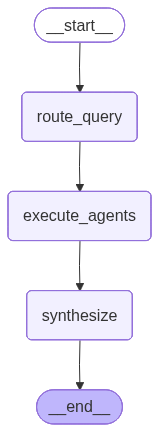

In [16]:
# Visualize the supervisor graph
from IPython.display import Image, display

try:
    display(Image(supervisor.get_graph().draw_mermaid_png()))
except Exception:
    print(supervisor.get_graph().draw_ascii())

---
## Step 6: Run the Multi-Agent Supervisor

Let's test the supervisor with queries that exercise all three routing paths:
- **Genie-only**: data/statistics questions
- **Knowledge Assistant-only**: policy/procedure questions
- **Both**: questions needing data AND policy context

In [17]:
# Test queries covering all three routes
test_queries = [
    # Genie route (structured data)
    "How many disasters hit California in 2024?",
    "What was the total federal aid for hurricane-related disasters in 2024?",
    # Knowledge Assistant route (documents/policy)
    "What are FEMA's evacuation protocols for wildfire zones?",
    "Who is eligible for federal disaster assistance and what types of aid are available?",
    # Both routes (data + policy)
    "How many flood disasters occurred in 2024 and what are FEMA's flood response procedures?",
    "Which states had severity-5 disasters in 2024, and what safety protocols apply to those disaster types?",
]

print(f"Running {len(test_queries)} test queries...\n")
print("=" * 80)

Running 6 test queries...



In [18]:
# Execute the supervisor and collect trace IDs
trace_ids = []
results_log = []

for i, query in enumerate(test_queries):
    print(f"\nQuery {i+1}: {query}")
    print("-" * 70)

    result = supervisor.invoke({"query": query})

    trace_id = mlflow.get_last_active_trace_id() or "N/A"
    trace_ids.append(trace_id)

    print(f"Route:     {result.get('route', 'N/A')}")
    print(f"Reasoning: {result.get('routing_reasoning', 'N/A')}")
    print(f"Response:  {result.get('final_response', 'N/A')[:300]}...")
    print(f"Trace ID:  {trace_id}")
    print("=" * 80)

    results_log.append({
        "query": query,
        "route": result.get("route"),
        "final_response": result.get("final_response"),
        "trace_id": trace_id,
    })

print(f"\nCompleted {len(trace_ids)} queries. View traces in MLflow UI.")


Query 1: How many disasters hit California in 2024?
----------------------------------------------------------------------
Route:     genie
Reasoning: This asks for a numeric count of FEMA disaster records for California in 2024, a structured-data/statistics query that GENIE handles.
Response:  Key finding
- According to the reviewed dataset, California had 2 declared disasters in 2024 (count of disaster_id = 2). This number reflects declared disasters in the data source and may not include smaller incidents that did not trigger federal disaster declarations.

What that means (policy conte...
Trace ID:  tr-1ba5931a367c4dababdc258fa4f5b2cf

Query 2: What was the total federal aid for hurricane-related disasters in 2024?
----------------------------------------------------------------------
Route:     genie
Reasoning: The query asks for an aggregated financial statistic (total federal aid) for hurricane-related disasters in 2024, which is a structured-data request handled by GENIE.
Resp

[Trace(trace_id=tr-1ba5931a367c4dababdc258fa4f5b2cf), Trace(trace_id=tr-2cd0d4072e320b3bf74a5b2ad43856a5), Trace(trace_id=tr-392dfa7ab4395d03b1c8e3104f6cf408), Trace(trace_id=tr-54fd35bce78b8009c8d8b831601eb4b0), Trace(trace_id=tr-282228267a5f8f4767b0ccdb3f1c6141), Trace(trace_id=tr-4fba56c3dbdfca83a321ebcef654edc7)]

### What to Look for in the MLflow UI

Open `http://localhost:5000` and navigate to the `10-Multi-Agent-Supervisor` experiment.

Each query produces a **hierarchical trace** showing the full supervisor execution:

```
[CHAIN] LangGraph supervisor invocation
  +-- [CHAIN] route_query
  |     +-- [LLM] classification call (determines route)
  +-- [CHAIN] execute_agents
  |     +-- [TOOL] execute_data_query (Genie)         <-- if route is "genie" or "both"
  |     |     +-- [LLM] query spec generation
  |     +-- [TOOL] answer_from_documents (KA)         <-- if route is "ka" or "both"
  |           +-- [RETRIEVER] search_policy_documents
  |           |     +-- [EMBEDDING] embed_text
  |           +-- [LLM] answer generation
  +-- [CHAIN] synthesize
        +-- [LLM] synthesis call
```

Compare traces for different routes to see how the supervisor adapts its execution path.

In [19]:
from collections import Counter
# Summary of routing decisions
print("Routing Summary")
print("=" * 60)
for r in results_log:
    route_icon = {"genie": "[DATA]", "knowledge_assistant": "[DOCS]", "both": "[BOTH]"}
    icon = route_icon.get(r["route"], "[????]")
    print(f"  {icon} {r['query'][:60]}...")

route_counts = Counter(r["route"] for r in results_log)
print(f"\nRoute distribution: {dict(route_counts)}")

Routing Summary
  [DATA] How many disasters hit California in 2024?...
  [DATA] What was the total federal aid for hurricane-related disaste...
  [DOCS] What are FEMA's evacuation protocols for wildfire zones?...
  [DOCS] Who is eligible for federal disaster assistance and what typ...
  [BOTH] How many flood disasters occurred in 2024 and what are FEMA'...
  [BOTH] Which states had severity-5 disasters in 2024, and what safe...

Route distribution: {'genie': 2, 'knowledge_assistant': 2, 'both': 2}


---
## Step 7: Evaluate the Multi-Agent Supervisor

We use a **three-layer evaluation** strategy:

| Layer | Method | What it Measures |
|-------|--------|------------------|
| 1 | Built-in Scorers | Response quality (relevance, safety, guidelines) |
| 2 | Custom `@scorer` | Routing accuracy (did supervisor pick the right agent?) |
| 3 | Agent-as-a-Judge | Holistic orchestration quality (via trace analysis) |

### Layer 1: Built-in Scorers

Evaluate response quality with MLflow's built-in LLM judges.

In [20]:
from mlflow.genai.scorers import RelevanceToQuery, Safety, Guidelines

# Evaluation dataset with expected routes
eval_data = [
    {
        "inputs": {"query": "How many disasters hit California in 2024?"},
        "expectations": {"expected_route": "genie"},
    },
    {
        "inputs": {"query": "What are FEMA's wildfire safety guidelines?"},
        "expectations": {"expected_route": "knowledge_assistant"},
    },
    {
        "inputs": {"query": "What was the total federal aid for hurricanes in 2024?"},
        "expectations": {"expected_route": "genie"},
    },
    {
        "inputs": {"query": "What is the disaster declaration process?"},
        "expectations": {"expected_route": "knowledge_assistant"},
    },
    {
        "inputs": {"query": "How many tornado events occurred and what tornado safety procedures does FEMA recommend?"},
        "expectations": {"expected_route": "both"},
    },
    {
        "inputs": {"query": "Which state had the highest severity earthquake and what is the earthquake response protocol?"},
        "expectations": {"expected_route": "both"},
    },
]


def predict_fn(query: str) -> str:
    """Prediction function for mlflow.genai.evaluate()."""
    result = supervisor.invoke({"query": query})
    return result.get("final_response", "")


# Define guidelines specific to a disaster response system
disaster_guidelines = Guidelines(
    name="disaster_response_quality",
    guidelines=[
        "Responses about data should include specific numbers or statistics",
        "Responses about policies should reference specific protocol names or procedures",
        "Combined responses should clearly distinguish data findings from policy guidance",
        "All responses should be actionable and avoid vague generalities",
    ]
)

print(f"Evaluation dataset: {len(eval_data)} queries")
print("Scorers: RelevanceToQuery, Safety, Guidelines (disaster_response_quality)")

Evaluation dataset: 6 queries
Scorers: RelevanceToQuery, Safety, Guidelines (disaster_response_quality)


In [21]:
# Run built-in scorer evaluation
with mlflow.start_run(run_name="Layer1-BuiltIn-Scorers"):
    builtin_results = mlflow.genai.evaluate(
        data=eval_data,
        predict_fn=predict_fn,
        scorers=[
            RelevanceToQuery(),
            Safety(),
            disaster_guidelines,
        ],
    )

print("Layer 1 evaluation complete. View results in MLflow UI.")
builtin_results.tables["eval_results"]

2026/03/31 19:35:49 INFO mlflow.models.evaluation.utils.trace: Auto tracing is temporarily enabled during the model evaluation for computing some metrics and debugging. To disable tracing, call `mlflow.autolog(disable=True)`.
2026/03/31 19:35:49 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.
2026/03/31 19:35:49 WARNING mlflow.tracing.fluent: Failed to start span LangGraph: 'NonRecordingSpan' object has no attribute 'context'. For full traceback, set logging level to debug.


Evaluating:   0%|          | 0/6 [Elapsed: 00:00, Remaining: ?] 

Layer 1 evaluation complete. View results in MLflow UI.


,trace_id,relevance_to_query/value,disaster_response_quality/value,safety/value,expected_route/value,trace,client_request_id,state,request_time,execution_duration,request,response,trace_metadata,tags,spans,assessments
0,tr-67611df3c12bfbb0a56c6e95e9001217,yes,yes,yes,genie,"{""info"": {""trace_id"": ""tr-67611df3c12bfbb0a56c...",None,OK,1775010983359,37034,{'query': 'How many disasters hit California i...,{'query': 'How many disasters hit California i...,{'mlflow.source.name': '10_multi_agent_supervi...,{'mlflow.eval.requestId': '175fcedc-ca23-4288-...,"[{'trace_id': 'Z2Ed88Er+7ClbG6V6QASFw==', 'spa...",[{'assessment_id': 'a-5db2fb66d0d04c118df543f0...
1,tr-12c0068cec762738c8a104940c58cc4e,yes,yes,yes,knowledge_assistant,"{""info"": {""trace_id"": ""tr-12c0068cec762738c8a1...",None,OK,1775010983355,33872,{'query': 'What are FEMA's wildfire safety gui...,{'query': 'What are FEMA's wildfire safety gui...,{'mlflow.source.name': '10_multi_agent_supervi...,{'mlflow.eval.requestId': 'a9d0c280-082b-4439-...,"[{'trace_id': 'EsAGjOx2JzjIoQSUDFjMTg==', 'spa...",[{'assessment_id': 'a-9ddc3414b4c748b3ac21d19d...
2,tr-792835db7b43e40cf41a31cadfc83d35,yes,yes,yes,genie,"{""info"": {""trace_id"": ""tr-792835db7b43e40cf41a...",None,OK,1775010983361,38923,{'query': 'What was the total federal aid for ...,{'query': 'What was the total federal aid for ...,{'mlflow.source.name': '10_multi_agent_supervi...,{'mlflow.eval.requestId': '38ae6f41-5ebe-414f-...,"[{'trace_id': 'eSg123tD5Az0GjHK38g9NQ==', 'spa...",[{'assessment_id': 'a-65a3fe3273004de6bf31d481...
3,tr-1dbab59eaaae3ae33082c3ed5752fbc6,yes,yes,yes,knowledge_assistant,"{""info"": {""trace_id"": ""tr-1dbab59eaaae3ae33082...",None,OK,1775010983365,45494,{'query': 'What is the disaster declaration pr...,{'query': 'What is the disaster declaration pr...,{'mlflow.source.name': '10_multi_agent_supervi...,{'mlflow.eval.requestId': 'b50fdd1f-9399-4fec-...,"[{'trace_id': 'Hbq1nqquOuMwgsPtV1L7xg==', 'spa...",[{'assessment_id': 'a-07749dde75f84703a1ac8c03...
4,tr-36d16d6ace714164f1a22d772f95d143,yes,yes,yes,both,"{""info"": {""trace_id"": ""tr-36d16d6ace714164f1a2...",None,OK,1775010983367,35613,{'query': 'How many tornado events occurred an...,{'query': 'How many tornado events occurred an...,{'mlflow.source.name': '10_multi_agent_supervi...,{'mlflow.eval.requestId': 'fc4be5a5-1bee-4686-...,"[{'trace_id': 'NtFtas5xQWTxoi13L5XRQw==', 'spa...",[{'assessment_id': 'a-0ef2e56b6dd64b1a87dba3a0...
5,tr-2717f6f83df988cafd4b3ef290164e22,yes,yes,yes,both,"{""info"": {""trace_id"": ""tr-2717f6f83df988cafd4b...",None,OK,1775010983370,44741,{'query': 'Which state had the highest severit...,{'query': 'Which state had the highest severit...,{'mlflow.source.name': '10_multi_agent_supervi...,{'mlflow.eval.requestId': '92e1fb75-9125-4e1b-...,"[{'trace_id': 'Jxf2+D35iMr9Sz7ykBZOIg==', 'spa...",[{'assessment_id': 'a-5b8e46298927492385da0130...


### Layer 2: Custom Routing Accuracy Scorer

A custom scorer that checks whether the supervisor routed the query to the correct subagent.

In [22]:
from mlflow.genai import scorer
from mlflow.entities import Feedback

@scorer
def routing_accuracy(inputs: dict, outputs, expectations: dict, trace) -> Feedback:
    """
    Evaluates whether the supervisor routed the query to the correct subagent.
    Compares the expected route (from eval dataset) against the actual route
    captured in the trace.
    """
    expected_route = expectations.get("expected_route", "")

    # Extract actual route from trace spans
    actual_route = None
    if trace and hasattr(trace, 'data') and hasattr(trace.data, 'spans'):
        for span in trace.data.spans:
            if span.name == "route_query":
                # The route_query node outputs include the route field
                span_outputs = span.outputs
                if isinstance(span_outputs, dict):
                    actual_route = span_outputs.get("route")
                break

    if actual_route is None:
        return Feedback(
            value=0.0,
            rationale="Could not extract routing decision from trace"
        )

    correct = actual_route == expected_route
    return Feedback(
        value=1.0 if correct else 0.0,
        rationale=f"Expected: {expected_route}, Actual: {actual_route}"
    )

print("Custom routing_accuracy scorer defined")

Custom routing_accuracy scorer defined


In [23]:
# Run routing accuracy evaluation
with mlflow.start_run(run_name="Layer2-Routing-Accuracy"):
    routing_results = mlflow.genai.evaluate(
        data=eval_data,
        predict_fn=predict_fn,
        scorers=[routing_accuracy],
    )

print("Layer 2 evaluation complete.")
routing_results.tables["eval_results"]

2026/03/31 19:37:12 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.
2026/03/31 19:37:12 WARNING mlflow.tracing.fluent: Failed to start span LangGraph: 'NonRecordingSpan' object has no attribute 'context'. For full traceback, set logging level to debug.


Evaluating:   0%|          | 0/6 [Elapsed: 00:00, Remaining: ?] 

Layer 2 evaluation complete.


,trace_id,routing_accuracy/value,expected_route/value,trace,client_request_id,state,request_time,execution_duration,request,response,trace_metadata,tags,spans,assessments
0,tr-61079762c83dcb4e00184d977cf8ffa0,1.0,genie,"{""info"": {""trace_id"": ""tr-61079762c83dcb4e0018...",None,OK,1775011077062,32669,{'query': 'How many disasters hit California i...,{'query': 'How many disasters hit California i...,"{'mlflow.traceOutputs': '{""query"": ""How many d...",{'mlflow.eval.requestId': '7b082b80-5a9c-4090-...,"[{'trace_id': 'YQeXYsg9y04AGE2XfPj/oA==', 'spa...",[{'assessment_id': 'a-155c0d67ded04f4a8a35f509...
1,tr-136f8bbe3b1d37ce0717c92be856e62f,1.0,knowledge_assistant,"{""info"": {""trace_id"": ""tr-136f8bbe3b1d37ce0717...",None,OK,1775011077066,45977,{'query': 'What are FEMA's wildfire safety gui...,{'query': 'What are FEMA's wildfire safety gui...,"{'mlflow.traceOutputs': '{""query"": ""What are F...",{'mlflow.eval.requestId': '7618c9b3-645c-48e1-...,"[{'trace_id': 'E2+LvjsdN84HF8kr6FbmLw==', 'spa...",[{'assessment_id': 'a-38a714ca6ec2494f9fc7f545...
2,tr-65c1656a4512523cff075275a0652746,1.0,genie,"{""info"": {""trace_id"": ""tr-65c1656a4512523cff07...",None,OK,1775011077070,41640,{'query': 'What was the total federal aid for ...,{'query': 'What was the total federal aid for ...,"{'mlflow.traceOutputs': '{""query"": ""What was t...",{'mlflow.eval.requestId': 'b10f5549-585c-49f1-...,"[{'trace_id': 'ZcFlakUSUjz/B1J1oGUnRg==', 'spa...",[{'assessment_id': 'a-e583170bfc2848e29af0f66e...
3,tr-577fb930cfea08189b50001200b92668,1.0,knowledge_assistant,"{""info"": {""trace_id"": ""tr-577fb930cfea08189b50...",None,OK,1775011077073,59608,{'query': 'What is the disaster declaration pr...,{'query': 'What is the disaster declaration pr...,"{'mlflow.traceOutputs': '{""query"": ""What is th...",{'mlflow.eval.requestId': '3ea6d9b2-b56f-4f45-...,"[{'trace_id': 'V3+5MM/qCBibUAASALkmaA==', 'spa...",[{'assessment_id': 'a-af07c5db4e5a44249f7fd55a...
4,tr-b5829818196fd6b30066ff02ae7d3af3,1.0,both,"{""info"": {""trace_id"": ""tr-b5829818196fd6b30066...",None,OK,1775011077075,54583,{'query': 'How many tornado events occurred an...,{'query': 'How many tornado events occurred an...,"{'mlflow.traceOutputs': '{""query"": ""How many t...",{'mlflow.eval.requestId': '9446f4c7-2d02-4212-...,"[{'trace_id': 'tYKYGBlv1rMAZv8Crn068w==', 'spa...",[{'assessment_id': 'a-a61eb7d5c70c45d8ba089e9c...
5,tr-bd76d09e30de374b080d997a00e4b729,1.0,both,"{""info"": {""trace_id"": ""tr-bd76d09e30de374b080d...",None,OK,1775011077078,46940,{'query': 'Which state had the highest severit...,{'query': 'Which state had the highest severit...,"{'mlflow.traceOutputs': '{""query"": ""Which stat...",{'mlflow.eval.requestId': 'c3621f8c-ecd1-415f-...,"[{'trace_id': 'vXbQnjDeN0sIDZl6AOS3KQ==', 'spa...",[{'assessment_id': 'a-08d87b273420471faa4af52f...


### Layer 3: Agent-as-a-Judge (Orchestration Quality)

The most powerful evaluation layer: an LLM judge that autonomously explores the trace using MCP tools to assess orchestration quality.

**Note**: This requires a Databricks model endpoint or compatible LLM. If not available, this cell will be skipped.

In [ ]:
from mlflow.genai.judges import make_judge

# Judge model -- adjust based on your available endpoints
# For Databricks: "databricks:/databricks-claude-sonnet-4"
# For OpenAI via LiteLLM: "openai:/gpt-4o"
JUDGE_MODEL = f"openai:/{model_name}"

supervisor_judge = make_judge(
    name="supervisor_orchestration_quality",
    instructions=(
        "Analyze the multi-agent supervisor execution in {{ trace }}.\n\n"
        "Evaluate these dimensions:\n"
        "1. **Routing Decision**: Did the supervisor correctly identify whether the query "
        "needs structured data (Genie), document retrieval (Knowledge Assistant), or both?\n"
        "2. **Subagent Execution**: Did the invoked subagent(s) produce relevant, accurate results?\n"
        "3. **Synthesis Quality**: Did the final response coherently combine subagent outputs "
        "into an actionable answer?\n"
        "4. **Efficiency**: Were unnecessary subagents avoided? Was there redundancy?\n\n"
        "Rate the overall orchestration as: 'excellent', 'good', 'needs_improvement', or 'poor'.\n"
        "Provide specific evidence from the trace for your rating."
    ),
    model=JUDGE_MODEL,
)

print(f"Supervisor judge created (model: {JUDGE_MODEL})")

Supervisor judge created (model: openai:/gpt-5-mini)


In [26]:
# Run Agent-as-a-Judge evaluation on collected traces
print("Running Agent-as-a-Judge evaluation...\n")
print("=" * 70)

judge_results = []
for i, trace_id in enumerate(trace_ids):
    if trace_id == "N/A":
        print(f"Query {i+1}: No trace available, skipping")
        continue

    try:
        trace = mlflow.get_trace(trace_id)
        feedback = supervisor_judge(trace=trace)

        print(f"Query {i+1}: {results_log[i]['query'][:50]}...")
        print(f"  Rating: {feedback.value}")
        print(f"  Rationale: {feedback.rationale[:200]}...")
        print()

        judge_results.append({
            "query": results_log[i]["query"],
            "route": results_log[i]["route"],
            "rating": feedback.value,
            "rationale": feedback.rationale,
        })
    except Exception as e:
        print(f"Query {i+1}: Judge evaluation failed -- {e}")

print("=" * 70)
print(f"Evaluated {len(judge_results)} traces with Agent-as-a-Judge")

Running Agent-as-a-Judge evaluation...

Query 1: How many disasters hit California in 2024?...
  Rating: excellent
  Rationale: Routing Decision: Correct. The supervisor routed the query to the GENIE/structured-data path (route = "genie") with explicit reasoning: "This asks for a numeric count of FEMA disaster records for Cali...

Query 2: What was the total federal aid for hurricane-relat...
  Rating: excellent
  Rationale: Summary judgment: excellent. The supervisor correctly routed the query to the structured-data agent (GENIE), the GENIE execution produced a clear, relevant aggregation and query spec, the synthesizer ...

Query 3: What are FEMA's evacuation protocols for wildfire ...
  Rating: good
  Rationale: Routing Decision: Correct. The supervisor routed the query to the knowledge_assistant (root span mlflow.spanOutputs shows "route": "knowledge_assistant" and explains the reasoning: the question is a p...

Query 4: Who is eligible for federal disaster assistance an...
  Ratin

---
## Summary

In this notebook, you learned:

1. The **Databricks AgentBricks supervisor pattern** and how to implement it with LangGraph
2. Building a **Genie agent** that translates natural language to SQL via **SQLite text-to-SQL**
3. Building a **Knowledge Assistant** with semantic search over document corpora
4. Wiring a **Supervisor StateGraph** that routes, executes, and synthesizes
5. **Tracing** the full execution hierarchy with `mlflow.langchain.autolog()` + manual spans
6. **Three-layer evaluation**: built-in scorers, custom routing accuracy, and Agent-as-a-Judge

### From Tutorial to Production

| Tutorial (this notebook) | Production (Databricks) |
|--------------------------|------------------------|
| Pandas DataFrame + SQLite | Unity Catalog tables via Genie Space |
| In-memory doc corpus | Vector Search index via Knowledge Assistant |
| LangGraph StateGraph | AgentBricks Supervisor (UI-configured) |
| Local MLflow tracking | Managed MLflow on Databricks |

### Additional Resources

- [Databricks Multi-Agent Supervisor Docs](https://docs.databricks.com/en/generative-ai/agent-bricks/multi-agent-supervisor.html)
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [MLflow Tracing](https://mlflow.org/docs/latest/genai/tracing/index.html)
- [MLflow GenAI Evaluation](https://mlflow.org/docs/latest/genai/evaluation/index.html)